
# IndicCorp v2 — Sentence Tokenization + BPE / WordPiece Subword Tokenization

**Dataset:** [ai4bharat/IndicCorpV2](https://huggingface.co/datasets/ai4bharat/IndicCorpV2)

This notebook:

1. Downloads monolingual data for one Indian language from IndicCorp v2 (paragraph-level) and
   sentence-tokenizes it.
2. Builds **train / dev / test** splits, where dev and test (1000 sentences each) are sampled so
   that their **sentence-length distribution** matches the overall corpus (i.e. they are *not*
   biased toward short or long sentences).
3. Trains **BPE** and **WordPiece** subword tokenizers on the training data (using the
   `tokenizers` library — the same algorithms used by GPT-2/RoBERTa (BPE) and BERT (WordPiece)).
4. Compares tokenization quality across **4 training-data sizes**: 100k, 300k, 500k, 1M sentences
   (vocab size held fixed).
5. Compares tokenization quality across **3 vocabulary sizes**: 20k, 30k, 50k (training size held
   fixed).

> **Note on runtime:** IndicCorpV2 is ~275 GB across all languages. This notebook streams only the
> language you select and stops once it has collected enough paragraphs, so it never downloads the
> full corpus. Training 14 tokenizer models (8 for the size experiment, 6 for the vocab experiment)
> can still take a while on 1M sentences of real text — reduce `MAX_TRAIN_SIZES` /
> `SUBSET_FOR_DEV_RUN` below if you just want to sanity-check the pipeline first.


## 0. Setup — install dependencies

In [3]:

!pip install -q datasets tokenizers huggingface_hub indic-nlp-library matplotlib pandas tqdm


In [4]:

import os
import re
import json
import random
import itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)



## 1. Choose language and download raw paragraphs from IndicCorp v2

IndicCorp v2 is published as one plain-text file (one paragraph per line) per language, exposed
through the HuggingFace `datasets` config `indiccorp_v2`. The available splits (from the dataset's
README) are:

| Language | split name | Language | split name |
|---|---|---|---|
| Assamese | `asm_Beng` | Malayalam | `mal_Mlym` |
| Bengali | `ben_Beng` | Marathi | `mar_Deva` |
| Bodo | `brx_Deva` | Manipuri | `mni_Mtei` |
| Dogri | `doi_Deva` | Nepali | `npi_Deva` |
| Konkani (Goan) | `gom_Deva` | Odia | `ory_Orya` |
| Gujarati | `guj_Gujr` | Punjabi | `pan_Guru` |
| **Hindi** | **`hin_Deva`** | Sanskrit | `san_Deva` |
| Kannada | `kan_Knda` | Sindhi | `snd_Deva` |
| Kashmiri | `kas_Arab` | Tamil | `tam_Taml` |
| Maithili | `mai_Deva` | Telugu | `tel_Telu` |
| | | Urdu | `urd_Arab` |
| | | Khasi | `khasi` |
| | | Santhali | `santhali` |

Change `LANGUAGE_SPLIT` below to work with a different language. We use **streaming** mode so we
never download the whole (multi-GB, sharded) file for the language — we just pull paragraphs until
we have enough sentences.


In [5]:

# ------------------------- CONFIG: change as needed -------------------------
LANGUAGE_SPLIT = "hin_Deva"          # e.g. "hin_Deva", "tam_Taml", "ben_Beng", ...
LANGUAGE_NAME   = "Hindi"

# We need at least: MAX_TRAIN_SIZE (largest of the 4 training sizes) + 2 * 1000 (dev+test)
# sentences after sentence-tokenization, with some slack because not every paragraph yields
# usable sentences.
MAX_TRAIN_SIZE  = 1_000_000
DEV_SIZE        = 1_000
TEST_SIZE       = 1_000
TARGET_SENTENCES = MAX_TRAIN_SIZE + DEV_SIZE + TEST_SIZE
PARAGRAPH_SAFETY_MARGIN = 1.4        # pull extra paragraphs since some are short/noisy
# ------------------------------------------------------------------------------


In [8]:

from datasets import load_dataset

def stream_paragraphs(language_split, n_target):
    # \"\"\"Stream paragraphs for `language_split` from IndicCorpV2 until we collect
    # n_target * PARAGRAPH_SAFETY_MARGIN paragraphs (or the split runs out).\"\"\"
    ds = load_dataset(
        "ai4bharat/IndicCorpV2",
        "indiccorp_v2",
        split=language_split,
        streaming=True,
    )
    paragraphs = []
    n_pull = int(n_target * PARAGRAPH_SAFETY_MARGIN)
    for ex in tqdm(ds, total=n_pull, desc=f"Streaming {language_split}"):
        text = ex["text"].strip()
        if text:
            paragraphs.append(text)
        if len(paragraphs) >= n_pull:
            break
    return paragraphs

raw_paragraphs = stream_paragraphs(LANGUAGE_SPLIT, TARGET_SENTENCES)
print(f"Pulled {len(raw_paragraphs):,} paragraphs for {LANGUAGE_NAME}")
print("\nSample paragraph:\n", raw_paragraphs[0][:400])


Streaming hin_Deva:   0%|          | 0/1402800 [00:00<?, ?it/s]

Pulled 1,402,800 paragraphs for Hindi

Sample paragraph:
 लोगों को बिलों संबंधी सुविधा देना ही उनका काम



## 2. Sentence tokenization

Each row in IndicCorp v2 is a **paragraph**, so we split every paragraph into sentences. We use
AI4Bharat's own `indic-nlp-library` sentence tokenizer (`indicnlp.tokenize.sentence_tokenize`),
which understands the Devanagari danda (`।`, `॥`) and other Indic punctuation, with a regex-based
fallback (splitting on `.`, `?`, `!`, `।`, `॥`, newlines) if the library isn't available for a
given script.


In [9]:

try:
    from indicnlp import common
    from indicnlp.tokenize import sentence_tokenize as indic_sent_tok
    # Map our split-language config to the ISO code indic-nlp-library expects
    ISO_MAP = {
        "hin_Deva": "hi", "ben_Beng": "bn", "guj_Gujr": "gu", "mar_Deva": "mr",
        "pan_Guru": "pa", "tam_Taml": "ta", "tel_Telu": "te", "kan_Knda": "kn",
        "mal_Mlym": "ml", "ory_Orya": "or", "asm_Beng": "as", "urd_Arab": "ur",
        "npi_Deva": "ne", "san_Deva": "sa", "mai_Deva": "mai", "snd_Deva": "sd",
    }
    LANG_ISO = ISO_MAP.get(LANGUAGE_SPLIT, "hi")
    HAVE_INDIC_NLP = True
    print(f"Using indic-nlp-library sentence tokenizer (lang='{LANG_ISO}')")
except Exception as e:
    HAVE_INDIC_NLP = False
    print("indic-nlp-library unavailable, will use regex fallback:", e)

_SENT_SPLIT_RE = re.compile(r"(?<=[।॥.!?])\s+")

def sentence_tokenize(paragraph, lang_iso="hi"):
    if HAVE_INDIC_NLP:
        try:
            sents = indic_sent_tok.sentence_split(paragraph, lang=lang_iso)
            sents = [s.strip() for s in sents if s.strip()]
            if sents:
                return sents
        except Exception:
            pass
    # Fallback: regex split on sentence-final punctuation
    sents = _SENT_SPLIT_RE.split(paragraph)
    return [s.strip() for s in sents if s.strip()]


Using indic-nlp-library sentence tokenizer (lang='hi')


In [10]:

def clean_sentence(s):
    s = re.sub(r"\s+", " ", s).strip()
    return s

MIN_SENT_LEN_CHARS = 5     # drop degenerate fragments
MAX_SENT_LEN_CHARS = 800   # drop pathological run-ons (likely mis-tokenized paragraphs)

all_sentences = []
seen = set()
for para in tqdm(raw_paragraphs, desc="Sentence-tokenizing"):
    for sent in sentence_tokenize(para, LANG_ISO if HAVE_INDIC_NLP else "hi"):
        sent = clean_sentence(sent)
        if not (MIN_SENT_LEN_CHARS <= len(sent) <= MAX_SENT_LEN_CHARS):
            continue
        if sent in seen:          # de-duplicate
            continue
        seen.add(sent)
        all_sentences.append(sent)
    if len(all_sentences) >= TARGET_SENTENCES:
        break

print(f"Collected {len(all_sentences):,} unique sentences (target: {TARGET_SENTENCES:,})")
assert len(all_sentences) >= (DEV_SIZE + TEST_SIZE + 10_000), \
    "Not enough sentences collected — increase PARAGRAPH_SAFETY_MARGIN or lower MAX_TRAIN_SIZE."


Sentence-tokenizing:   0%|          | 0/1402800 [00:00<?, ?it/s]

Collected 1,002,003 unique sentences (target: 1,002,000)



## 3. Train / Dev / Test split — length-stratified sampling

The task requires dev and test sets that **cover the full range of sentence lengths** rather than
clustering around one length (e.g. only short sentences). We do this by:

1. Computing sentence length (in whitespace-separated words) for every sentence.
2. Bucketing sentences into length **deciles** (10 bins of roughly equal population, based on the
   overall length distribution).
3. Sampling `DEV_SIZE` / `TEST_SIZE` sentences **proportionally from every bin**, so the length
   histogram of dev/test mirrors the histogram of the full corpus — short, medium, and long
   sentences are all represented, and no two sets are skewed toward "similar" lengths.
4. Everything not selected for dev/test becomes the training pool (later subsampled into the four
   training sizes).


In [11]:

def word_len(s):
    return len(s.split())

lengths = np.array([word_len(s) for s in all_sentences])
df = pd.DataFrame({"sentence": all_sentences, "length": lengths})

# 10 length bins based on quantiles of the actual distribution
N_BINS = 10
df["bin"] = pd.qcut(df["length"], q=N_BINS, duplicates="drop")
bin_counts = df["bin"].value_counts().sort_index()
print(bin_counts)


bin
(0.999, 8.0]     136878
(8.0, 10.0]       94415
(10.0, 12.0]     103925
(12.0, 14.0]     102799
(14.0, 16.0]      95510
(16.0, 18.0]      84459
(18.0, 21.0]     104339
(21.0, 25.0]     100167
(25.0, 31.0]      88222
(31.0, 184.0]     91289
Name: count, dtype: int64


In [12]:

def stratified_sample(frame, n_total, n_bins_col="bin", seed=42):
    """Sample n_total rows from `frame`, proportionally across its length bins,
    without replacement, and return (sampled_df, remaining_df)."""
    rng = np.random.RandomState(seed)
    bins = frame[n_bins_col].cat.categories
    picks = []
    remaining_frames = []
    # proportional allocation per bin (largest-remainder method to hit n_total exactly)
    bin_sizes = frame.groupby(n_bins_col, observed=True).size()
    proportions = bin_sizes / bin_sizes.sum()
    raw_alloc = proportions * n_total
    alloc = np.floor(raw_alloc).astype(int)
    shortfall = n_total - alloc.sum()
    remainder_order = (raw_alloc - alloc).sort_values(ascending=False).index
    for b in remainder_order[:shortfall]:
        alloc[b] += 1

    for b in bins:
        sub = frame[frame[n_bins_col] == b]
        k = min(alloc.get(b, 0), len(sub))
        chosen = sub.sample(n=k, random_state=seed)
        picks.append(chosen)
    sampled = pd.concat(picks).sample(frac=1.0, random_state=seed)  # shuffle
    remaining = frame.drop(sampled.index)
    return sampled, remaining

# 1) sample TEST first, 2) sample DEV from what's left, 3) rest -> train pool
test_df, pool_df = stratified_sample(df, TEST_SIZE, seed=42)
dev_df,  pool_df = stratified_sample(pool_df, DEV_SIZE, seed=43)
train_pool_df = pool_df.sample(frac=1.0, random_state=44).reset_index(drop=True)

print(f"train pool: {len(train_pool_df):,} | dev: {len(dev_df):,} | test: {len(test_df):,}")


train pool: 1,000,003 | dev: 1,000 | test: 1,000


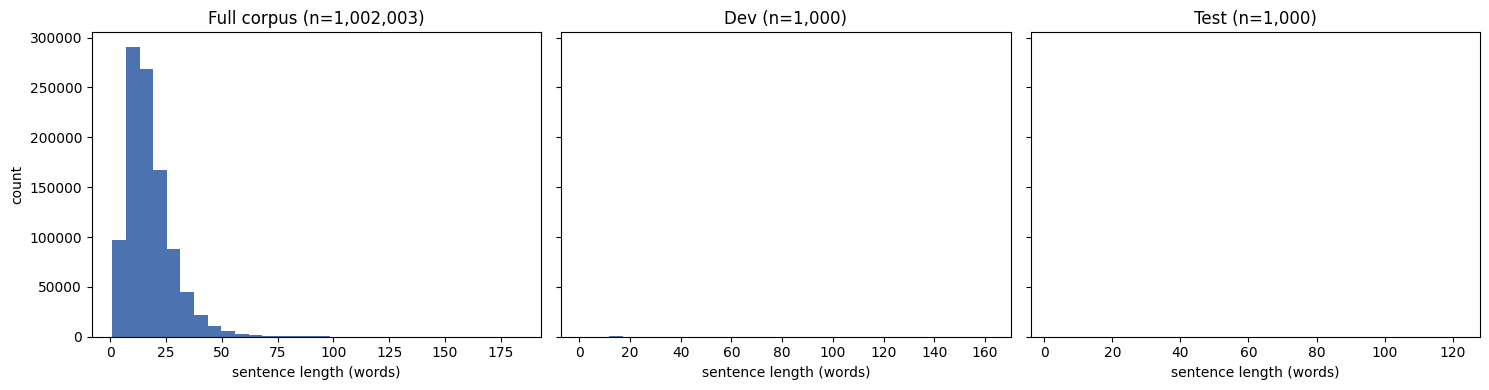

count    1.002003e+06
mean     1.798791e+01
std      1.070400e+01
min      1.000000e+00
25%      1.100000e+01
50%      1.600000e+01
75%      2.300000e+01
max      1.840000e+02
Name: length, dtype: float64

Dev:
 count    1000.000000
mean       18.225000
std        12.038326
min         1.000000
25%        11.000000
50%        16.000000
75%        22.000000
max       162.000000
Name: length, dtype: float64

Test:
 count    1000.00000
mean       17.94200
std        10.54219
min         2.00000
25%        11.00000
50%        16.00000
75%        22.25000
max       122.00000
Name: length, dtype: float64


In [13]:

# Sanity check: dev/test length distributions should resemble the full corpus,
# not just one narrow band of lengths.
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, (name, d) in zip(ax, [("Full corpus", df), ("Dev", dev_df), ("Test", test_df)]):
    a.hist(d["length"], bins=30, color="#4C72B0")
    a.set_title(f"{name} (n={len(d):,})")
    a.set_xlabel("sentence length (words)")
ax[0].set_ylabel("count")
plt.tight_layout()
plt.show()

print(df["length"].describe())
print("\nDev:\n", dev_df["length"].describe())
print("\nTest:\n", test_df["length"].describe())


In [14]:

# Persist the splits to disk (plain text, one sentence per line) — used by tokenizer training.
def write_lines(path, sentences):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(s + "\n")

train_pool_path = DATA_DIR / "train_pool.txt"
dev_path        = DATA_DIR / "dev.txt"
test_path       = DATA_DIR / "test.txt"

write_lines(train_pool_path, train_pool_df["sentence"].tolist())
write_lines(dev_path,        dev_df["sentence"].tolist())
write_lines(test_path,       test_df["sentence"].tolist())

print("Train pool size:", len(train_pool_df))
print("Saved:", train_pool_path, dev_path, test_path)


Train pool size: 1000003
Saved: data/train_pool.txt data/dev.txt data/test.txt



## 4. BPE and WordPiece — training utilities

We use HuggingFace's `tokenizers` library, which implements both algorithms exactly as used in
production models:

- **BPE** (Byte-Pair Encoding) — iteratively merges the most frequent adjacent symbol pair,
  starting from characters, until the target vocabulary size is reached (as in GPT-2/RoBERTa).
- **WordPiece** — similar bottom-up merging, but merges are chosen to maximize the **likelihood**
  of the training data (score = freq(pair) / (freq(first) * freq(second))) rather than raw
  frequency (as in BERT).

Both are trained with the same pre-tokenizer (Unicode-aware whitespace splitting) and the same
special tokens, so comparisons between them are fair.


In [15]:

from tokenizers import Tokenizer, normalizers, pre_tokenizers, decoders
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer
from tokenizers.normalizers import NFKC

SPECIAL_TOKENS = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]

def build_bpe_tokenizer():
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.normalizer = NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    tok.decoder = decoders.BPEDecoder()
    return tok

def build_wordpiece_tokenizer():
    tok = Tokenizer(WordPiece(unk_token="[UNK]"))
    tok.normalizer = NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    tok.decoder = decoders.WordPiece()
    return tok

def train_bpe(files, vocab_size):
    tok = build_bpe_tokenizer()
    trainer = BpeTrainer(vocab_size=vocab_size, min_frequency=2,
                          special_tokens=SPECIAL_TOKENS, show_progress=False)
    tok.train(files=files, trainer=trainer)
    return tok

def train_wordpiece(files, vocab_size):
    tok = build_wordpiece_tokenizer()
    trainer = WordPieceTrainer(vocab_size=vocab_size, min_frequency=2,
                                special_tokens=SPECIAL_TOKENS, show_progress=False)
    tok.train(files=files, trainer=trainer)
    return tok


In [16]:

def make_training_subset(n_sentences, seed=44, out_path=None):
    # \"\"\"Write the first n_sentences of the (already shuffled) train pool to a file.\"\"\"
    sub = train_pool_df["sentence"].iloc[:n_sentences].tolist()
    if out_path is None:
        out_path = DATA_DIR / f"train_{n_sentences}.txt"
    write_lines(out_path, sub)
    return out_path, sub


In [17]:

def evaluate_tokenizer(tok, sentences):
    # \"\"\"Compute standard subword-tokenization diagnostics on a list of raw sentences.\"\"\"
    total_tokens = 0
    total_words = 0
    total_chars = 0
    unk_id = tok.token_to_id("[UNK]")
    n_unk = 0
    multi_token_words = 0

    for s in sentences:
        enc = tok.encode(s)
        total_tokens += len(enc.ids)
        total_chars += len(s)
        n_unk += sum(1 for i in enc.ids if i == unk_id)

        words = s.split()
        total_words += len(words)
        for w in words:
            w_enc = tok.encode(w)
            if len(w_enc.ids) > 1:
                multi_token_words += 1

    vocab_size = tok.get_vocab_size()
    return {
        "vocab_size": vocab_size,
        "avg_tokens_per_sentence": total_tokens / len(sentences),
        "fertility_tokens_per_word": total_tokens / max(total_words, 1),
        "chars_per_token": total_chars / max(total_tokens, 1),
        "pct_words_split_multi_token": 100 * multi_token_words / max(total_words, 1),
        "unk_rate_pct": 100 * n_unk / max(total_tokens, 1),
    }



## 5. Experiment A — Impact of **training-data size** on tokenization

Vocabulary size is held fixed at **30,000** while we vary the amount of training data:
**100,000 / 300,000 / 500,000 / 1,000,000** sentences. For each size we train a fresh BPE and a
fresh WordPiece model, then evaluate both on the same held-out **dev** and **test** sets.


In [18]:

TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]
FIXED_VOCAB_FOR_SIZE_EXPERIMENT = 30_000

dev_sentences  = dev_df["sentence"].tolist()
test_sentences = test_df["sentence"].tolist()

size_experiment_rows = []
size_experiment_tokenizers = {}   # (algo, size) -> Tokenizer

for n in TRAIN_SIZES:
    n_eff = min(n, len(train_pool_df))
    if n_eff < n:
        print(f"WARNING: requested {n:,} sentences but only {n_eff:,} available; using {n_eff:,}.")
    train_file, _ = make_training_subset(n_eff)

    for algo_name, trainer_fn in [("BPE", train_bpe), ("WordPiece", train_wordpiece)]:
        tok = trainer_fn([str(train_file)], FIXED_VOCAB_FOR_SIZE_EXPERIMENT)
        size_experiment_tokenizers[(algo_name, n_eff)] = tok

        for split_name, split_sents in [("dev", dev_sentences), ("test", test_sentences)]:
            metrics = evaluate_tokenizer(tok, split_sents)
            metrics.update({
                "algorithm": algo_name,
                "train_size": n_eff,
                "split": split_name,
            })
            size_experiment_rows.append(metrics)

size_df = pd.DataFrame(size_experiment_rows)
size_df = size_df[["algorithm", "train_size", "split", "vocab_size",
                    "avg_tokens_per_sentence", "fertility_tokens_per_word",
                    "chars_per_token", "pct_words_split_multi_token", "unk_rate_pct"]]
size_df.sort_values(["algorithm", "split", "train_size"])


,algorithm,train_size,split,vocab_size,avg_tokens_per_sentence,fertility_tokens_per_word,chars_per_token,pct_words_split_multi_token,unk_rate_pct
0,BPE,100000,dev,30000,21.385,1.173388,4.320365,13.333333,0.004676
4,BPE,300000,dev,30000,21.313,1.169438,4.334960,13.048011,0.000000
8,BPE,500000,dev,30000,21.299,1.168669,4.337809,13.020576,0.000000
12,BPE,1000000,dev,30000,21.314,1.169492,4.334756,13.064472,0.000000
1,BPE,100000,test,30000,20.890,1.164307,4.337386,12.924980,0.014361
5,BPE,300000,test,30000,20.832,1.161075,4.349462,12.690893,0.004800
9,BPE,500000,test,30000,20.831,1.161019,4.349671,12.702040,0.004801
13,BPE,1000000,test,30000,20.842,1.161632,4.347375,12.707613,0.004798
2,WordPiece,100000,dev,30000,21.566,1.183320,4.284105,13.777778,0.004637
6,WordPiece,300000,dev,30000,21.497,1.179534,4.297856,13.481481,0.000000


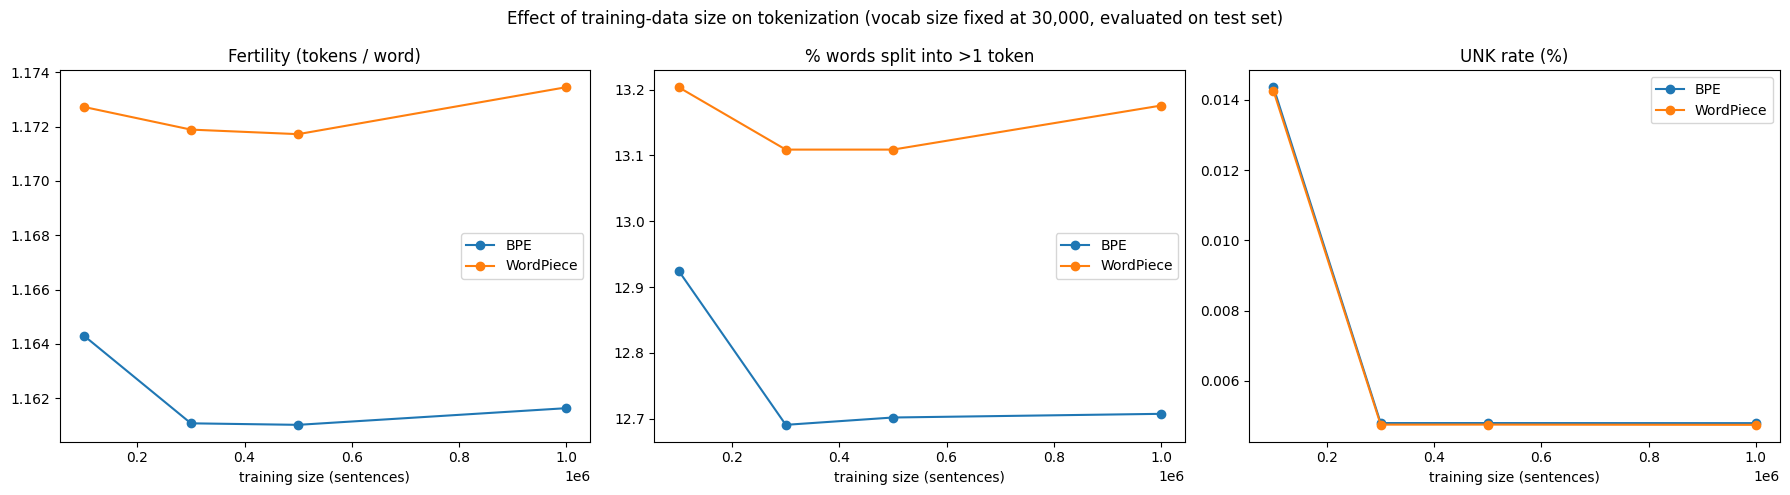

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["fertility_tokens_per_word", "pct_words_split_multi_token", "unk_rate_pct"]
titles = ["Fertility (tokens / word)", "% words split into >1 token", "UNK rate (%)"]

plot_df = size_df[size_df["split"] == "test"]
for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for algo in ["BPE", "WordPiece"]:
        sub = plot_df[plot_df["algorithm"] == algo].sort_values("train_size")
        ax.plot(sub["train_size"], sub[metric], marker="o", label=algo)
    ax.set_xlabel("training size (sentences)")
    ax.set_title(title)
    ax.legend()
fig.suptitle(f"Effect of training-data size on tokenization (vocab size fixed at "
             f"{FIXED_VOCAB_FOR_SIZE_EXPERIMENT:,}, evaluated on test set)")
plt.tight_layout()
plt.show()



## 6. Experiment B — Impact of **vocabulary size** on tokenization

Training-data size is held fixed at the **largest available size** (up to 1,000,000 sentences)
while we vary vocabulary size: **20,000 / 30,000 / 50,000**.


In [20]:

VOCAB_SIZES = [20_000, 30_000, 50_000]
FIXED_TRAIN_SIZE_FOR_VOCAB_EXPERIMENT = min(1_000_000, len(train_pool_df))

vocab_train_file, _ = make_training_subset(FIXED_TRAIN_SIZE_FOR_VOCAB_EXPERIMENT,
                                            out_path=DATA_DIR / "train_for_vocab_experiment.txt")

vocab_experiment_rows = []
vocab_experiment_tokenizers = {}

for v in VOCAB_SIZES:
    for algo_name, trainer_fn in [("BPE", train_bpe), ("WordPiece", train_wordpiece)]:
        tok = trainer_fn([str(vocab_train_file)], v)
        vocab_experiment_tokenizers[(algo_name, v)] = tok

        for split_name, split_sents in [("dev", dev_sentences), ("test", test_sentences)]:
            metrics = evaluate_tokenizer(tok, split_sents)
            metrics.update({
                "algorithm": algo_name,
                "vocab_size_target": v,
                "split": split_name,
            })
            vocab_experiment_rows.append(metrics)

vocab_df = pd.DataFrame(vocab_experiment_rows)
vocab_df = vocab_df[["algorithm", "vocab_size_target", "split", "vocab_size",
                      "avg_tokens_per_sentence", "fertility_tokens_per_word",
                      "chars_per_token", "pct_words_split_multi_token", "unk_rate_pct"]]
vocab_df.sort_values(["algorithm", "split", "vocab_size_target"])


,algorithm,vocab_size_target,split,vocab_size,avg_tokens_per_sentence,fertility_tokens_per_word,chars_per_token,pct_words_split_multi_token,unk_rate_pct
0,BPE,20000,dev,20000,21.866,1.199781,4.225327,14.875171,0.000000
4,BPE,30000,dev,30000,21.314,1.169492,4.334756,13.064472,0.000000
8,BPE,50000,dev,50000,20.849,1.143978,4.431436,11.495199,0.000000
1,BPE,20000,test,20000,21.385,1.191896,4.236989,14.485565,0.004676
5,BPE,30000,test,30000,20.842,1.161632,4.347375,12.707613,0.004798
9,BPE,50000,test,50000,20.416,1.137889,4.438088,11.303088,0.004898
2,WordPiece,20000,dev,20000,22.213,1.218820,4.159321,15.769547,0.000000
6,WordPiece,30000,dev,30000,21.510,1.180247,4.295258,13.541838,0.000000
10,WordPiece,50000,dev,50000,20.953,1.149684,4.409440,11.698217,0.000000
3,WordPiece,20000,test,20000,21.730,1.211125,4.169719,15.321592,0.004602


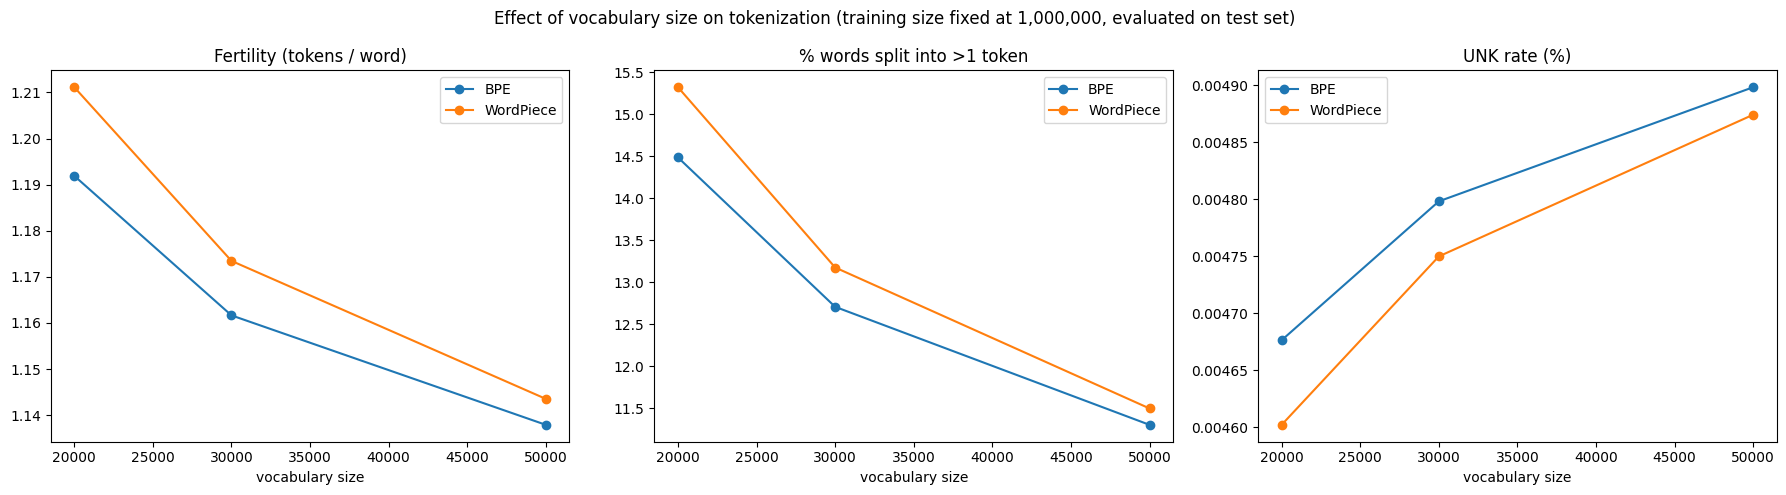

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = vocab_df[vocab_df["split"] == "test"]
for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for algo in ["BPE", "WordPiece"]:
        sub = plot_df[plot_df["algorithm"] == algo].sort_values("vocab_size_target")
        ax.plot(sub["vocab_size_target"], sub[metric], marker="o", label=algo)
    ax.set_xlabel("vocabulary size")
    ax.set_title(title)
    ax.legend()
fig.suptitle(f"Effect of vocabulary size on tokenization (training size fixed at "
             f"{FIXED_TRAIN_SIZE_FOR_VOCAB_EXPERIMENT:,}, evaluated on test set)")
plt.tight_layout()
plt.show()



## 7. Qualitative comparison

A few example sentences from the test set, tokenized by every BPE/WordPiece model from Experiment
A, side by side — useful for eyeballing how bigger training data / vocab changes segmentation
(e.g. more sentences → fewer character-level fallbacks; bigger vocab → more whole words kept
intact as single tokens).


In [22]:

example_sentences = test_sentences[:3]

for sent in example_sentences:
    print("=" * 100)
    print("SENTENCE:", sent)
    for n in TRAIN_SIZES:
        for algo in ["BPE", "WordPiece"]:
            tok = size_experiment_tokenizers[(algo, min(n, len(train_pool_df)))]
            pieces = tok.encode(sent).tokens
            print(f"  [{algo:9s} | train={n:>9,}] ({len(pieces)} tokens): {pieces}")


SENTENCE: उन्होंने कहा कि सभी दोषियों को एक साथ ही फांसी हो सकती है अलग-अलग नहीं।
  [BPE       | train=  100,000] (18 tokens): ['उन्होंने', 'कहा', 'कि', 'सभी', 'दोषियों', 'को', 'एक', 'साथ', 'ही', 'फांसी', 'हो', 'सकती', 'है', 'अलग', '-', 'अलग', 'नहीं', '।']
  [WordPiece | train=  100,000] (18 tokens): ['उन्होंने', 'कहा', 'कि', 'सभी', 'दोषियों', 'को', 'एक', 'साथ', 'ही', 'फांसी', 'हो', 'सकती', 'है', 'अलग', '-', 'अलग', 'नहीं', '।']
  [BPE       | train=  300,000] (18 tokens): ['उन्होंने', 'कहा', 'कि', 'सभी', 'दोषियों', 'को', 'एक', 'साथ', 'ही', 'फांसी', 'हो', 'सकती', 'है', 'अलग', '-', 'अलग', 'नहीं', '।']
  [WordPiece | train=  300,000] (18 tokens): ['उन्होंने', 'कहा', 'कि', 'सभी', 'दोषियों', 'को', 'एक', 'साथ', 'ही', 'फांसी', 'हो', 'सकती', 'है', 'अलग', '-', 'अलग', 'नहीं', '।']
  [BPE       | train=  500,000] (18 tokens): ['उन्होंने', 'कहा', 'कि', 'सभी', 'दोषियों', 'को', 'एक', 'साथ', 'ही', 'फांसी', 'हो', 'सकती', 'है', 'अलग', '-', 'अलग', 'नहीं', '।']
  [WordPiece | train=  500,000] (18 tokens)


## 8. Save tokenizers and result tables

All trained tokenizer models and the two results tables are written to disk so they can be
re-loaded without retraining.


In [24]:

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

for (algo, n), tok in size_experiment_tokenizers.items():
    tok.save(str(MODELS_DIR / f"{algo.lower()}_trainsize_{n}_vocab_{FIXED_VOCAB_FOR_SIZE_EXPERIMENT}.json"))

for (algo, v), tok in vocab_experiment_tokenizers.items():
    tok.save(str(MODELS_DIR / f"{algo.lower()}_vocab_{v}_trainsize_{FIXED_TRAIN_SIZE_FOR_VOCAB_EXPERIMENT}.json"))

size_df.to_csv("results_training_size_experiment.csv", index=False)
vocab_df.to_csv("results_vocab_size_experiment.csv", index=False)

print("Saved tokenizer models to:", MODELS_DIR.resolve())
print("Saved results tables: results_training_size_experiment.csv, results_vocab_size_experiment.csv")


Saved tokenizer models to: /Users/mjgandhi2305/Semester_7/ILLM/A3/models
Saved results tables: results_training_size_experiment.csv, results_vocab_size_experiment.csv



## 9. Summary / discussion (fill in after running)

Typical patterns to look for once the experiments above have run on real data:

- **Training-data size (Section 5):** as training data grows, both BPE and WordPiece see more
  distinct word forms, so common morphemes/words are more likely to already exist as single
  merged tokens in the vocab → **fertility (tokens/word) tends to drop** and the **% of words
  split into multiple subwords decreases**, up to a point of diminishing returns.
- **Vocabulary size (Section 6):** a larger vocabulary can store more whole words / longer
  subwords directly → fertility drops and average tokens-per-sentence decreases, at the cost of a
  bigger embedding table and more rare, low-frequency vocabulary entries.
- **BPE vs. WordPiece:** WordPiece's likelihood-based merge criterion tends to favor merges that
  are more "informative" relative to their component frequencies, which can lead to slightly
  different (often marginally more linguistically coherent) subword boundaries than BPE's
  frequency-only criterion, even though final fertility numbers are usually close.

Replace this cell with your own numeric observations once you've executed the notebook end-to-end
on your chosen language.
